$$
\frac{\partial V}{\partial t} + \frac{1}{2} v S^2 \frac{\partial^2 V}{\partial S^2} + \rho \sigma v S \frac{\partial^2 V}{\partial S \partial v} + \frac{1}{2} \sigma^2 v \frac{\partial^2 V}{\partial v^2} + rS\frac{\partial V}{\partial S} + k(\theta - v) \frac{\partial V}{\partial v} - rV = 0
$$

In [45]:
S0 = 100
v0 = 0.04
K = 100
T = 1

r = 0.02
kappa = 2.0 # Mean-reversion rate
theta = 0.04 # Long term variance
sigma = 0.5 # Volatility of variance
rho = -0.7 # Correlation between S and V

In [53]:
S_max = 4 * S0
S_min = 0
v_max = 0.5
v_min = 0

N_S = 1000
N_v = 1000
N_T = 2000

c = 20 # Asset price grid step clustering parameter

d = 0.05 # Variance grid step clustering parameter

theta_MCS = 1/3 # MCS ADI parameter

In [55]:
import barrier_option_heston as boh
import importlib
importlib.reload(boh)

S_grid = boh.create_nonuniform_asset_price_grid(S_min, S_max, K, N_S, c)
v_grid = boh.create_nonuniform_variance_grid(v_min, v_max, N_v, d)
U = boh.initialize_option_price_grid_call(S_grid, v_grid, K)
price_surface = boh.solve_heston_adi_vanilla_call(
    T, N_T, U, theta_MCS, S_grid, v_grid, r, kappa, theta, sigma, rho, K
)   
price = boh.price_option_heston(price_surface, S0, v0, S_grid, v_grid)
print(f"Vanilla call option price under Heston model: {price:.4f}")

Vanilla call option price under Heston model: 8.3099


N_T =    60  (60/1200)  price = 8.264967
N_T =   120  (120/1200)  price = 8.315136
N_T =   180  (180/1200)  price = 8.332178
N_T =   240  (240/1200)  price = 8.340740
N_T =   300  (300/1200)  price = 8.345886
N_T =   360  (360/1200)  price = 8.349320
N_T =   420  (420/1200)  price = 8.351773
N_T =   480  (480/1200)  price = 8.353614
N_T =   540  (540/1200)  price = 8.355045
N_T =   600  (600/1200)  price = 8.356190
N_T =   660  (660/1200)  price = 8.357128
N_T =   720  (720/1200)  price = 8.357908
N_T =   780  (780/1200)  price = 8.358569
N_T =   840  (840/1200)  price = 8.359135
N_T =   900  (900/1200)  price = 8.359626
N_T =   960  (960/1200)  price = 8.360056
N_T =  1020  (1020/1200)  price = 8.360435
N_T =  1080  (1080/1200)  price = 8.360771
N_T =  1140  (1140/1200)  price = 8.361073
N_T =  1200  (1200/1200)  price = 8.361344


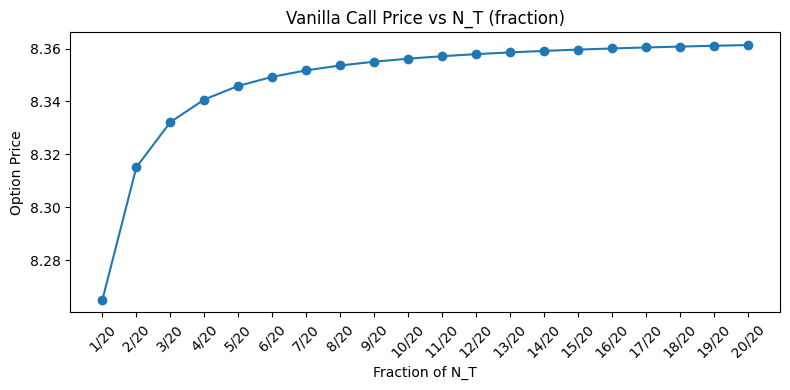

In [51]:

import matplotlib.pyplot as plt

n_steps = 20
nt_values = [max(1, round(k * N_T / n_steps)) for k in range(1, n_steps + 1)]
prices = []

for nt in nt_values:
    U_tmp = boh.initialize_option_price_grid_call(S_grid, v_grid, K)
    ps = boh.solve_heston_adi_vanilla_call(
        T, nt, U_tmp, theta_MCS, S_grid, v_grid, r, kappa, theta, sigma, rho, K
    )
    p = boh.price_option_heston(ps, S0, v0, S_grid, v_grid)
    prices.append(p)
    print(f"N_T = {nt:5d}  ({nt}/{N_T})  price = {p:.6f}")

plt.figure(figsize=(8, 4))
plt.plot([nt / N_T for nt in nt_values], prices, marker='o')
plt.xlabel("Fraction of N_T")
plt.ylabel("Option Price")
plt.title("Vanilla Call Price vs N_T (fraction)")
plt.xticks([k / n_steps for k in range(1, n_steps + 1)],
           [f"{k}/{n_steps}" for k in range(1, n_steps + 1)], rotation=45)
plt.tight_layout()
plt.show()
